In [1]:
import torch
import torch.nn as nn
import dataloader as dl
import torch.optim as SGD
import torch.nn.init as init
import matplotlib.pyplot as plt

# Creating cnn Layers

In [2]:
conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
linear = nn.Linear(64*7*7, 10)

# weight initialization

In [3]:
init.kaiming_uniform_(conv1.weight, nonlinearity='relu')
init.kaiming_uniform_(conv2.weight, nonlinearity='relu')
init.kaiming_uniform_(linear.weight)

Parameter containing:
tensor([[-8.4886e-03,  1.2159e-04, -2.3037e-03,  ..., -1.0334e-02,
          2.6354e-02, -4.3473e-02],
        [ 3.9074e-02, -3.7969e-02,  4.2958e-02,  ..., -7.9812e-03,
         -3.6831e-03, -2.4118e-02],
        [-3.4570e-02,  1.8615e-02,  3.9707e-02,  ...,  8.9278e-04,
         -3.6520e-03,  2.5273e-02],
        ...,
        [-4.3555e-03, -4.1398e-02, -1.1952e-02,  ..., -2.9159e-02,
         -4.1027e-02, -2.6820e-02],
        [-2.5674e-02,  2.3276e-05,  2.0204e-02,  ..., -1.0395e-02,
          2.1695e-02, -2.0047e-02],
        [ 9.7580e-05,  3.1808e-02,  3.3814e-02,  ...,  2.0433e-02,
          9.8472e-03, -5.6383e-03]], requires_grad=True)

# Creating Cnn model

In [4]:
cnn = nn.Sequential(
    conv1,
    nn.ReLU(),  
    nn.MaxPool2d(kernel_size=2, stride=2),
    
    conv2,
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    
    nn.Flatten(),
    linear,
)

# Training the Cnn model

### Setting up the loss function and optimizer

In [5]:
learning_rate = 0.01
num_epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = SGD.SGD(cnn.parameters(), lr=learning_rate)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cnn.to(device)

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=10, bias=True)
)

In [6]:

train_losses = []
val_losses = []
train_accs = []
val_accs = []
loader = dl.build_loader(64)

for epoch in range(num_epochs):
    # TRAINING
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for data, target in loader['train_loader_nn']:
        data = data.unsqueeze(1).to(device)  # unsqueeze to add channel dimension as cnn needs 4D input
        target = target.to(device)
        
        optimizer.zero_grad()
        output = cnn(data)
        loss = loss_function(output, target)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(output, 1)
        train_total += target.size(0)
        train_correct += (predicted == target).sum().item()
    
    # VALIDATION
    cnn.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for data, target in loader['val_loader_nn']:
            data = data.unsqueeze(1).to(device)  # unsqueeze to add channel dimension as cnn needs 4D input
            target = target.to(device)
                        
            output = cnn(data)
            loss = loss_function(output, target)
            
            val_loss += loss.item()
            _, predicted = torch.max(output, 1)
            val_total += target.size(0)
            val_correct += (predicted == target).sum().item()
    
    # Calculate averages
    train_loss = train_loss / len(loader['train_loader_nn'])
    val_loss = val_loss / len(loader['val_loader_nn'])
    train_acc = 100 * train_correct / train_total
    val_acc = 100 * val_correct / val_total
    
    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # Print progress
    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
    print(f'  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 0.4744 | Train Acc: 86.16%
  Val Loss: 0.2458 | Val Acc: 92.80%
Epoch 2/20
  Train Loss: 0.2112 | Train Acc: 93.84%
  Val Loss: 0.1857 | Val Acc: 94.72%
Epoch 3/20
  Train Loss: 0.1531 | Train Acc: 

# Training and validation loss

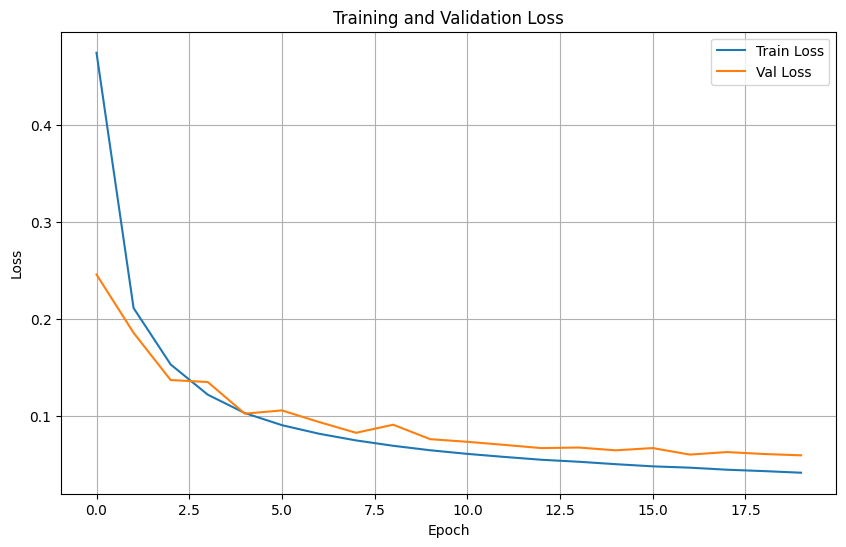

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Training and Validation accuracy

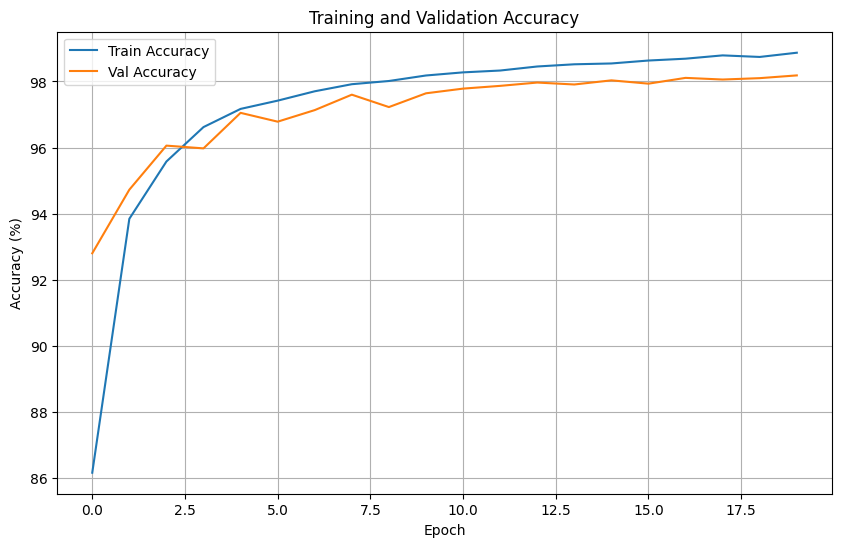

In [8]:

plt.figure(figsize=(10, 6))
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


# Testing the Cnn model

In [9]:
test_acc_list = []

for data, target in loader['test_loader_nn']:
    data = data.unsqueeze(1).to(device)
    target = target.to(device)
    
    output = cnn(data)
    _, predicted = torch.max(output, 1)
    
    test_total = target.size(0)
    test_correct = (predicted == target).sum().item()
    
    test_acc = 100 * test_correct / test_total
    test_acc_list.append(test_acc)
    
average_test_acc = sum(test_acc_list) / len(test_acc_list)

print(f'Average Test Accuracy over all batches: {average_test_acc:.2f}%')

Average Test Accuracy over all batches: 98.32%
